In [103]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
villager_df = pd.read_csv('villagers.csv')
rank_df = pd.read_csv('rankings.csv')

conn = sqlite3.connect(':memory:')
villager_df.to_sql('villagers', conn, index=False)
rank_df.to_sql('ranking', conn, index=False)

print(f"Villagers table: {len(villager_df)} rows, columns: {list(villager_df.columns)}")
print(f"Rankings table: {len(rank_df)} rows, columns: {list(rank_df.columns)}")

Villagers table: 391 rows, columns: ['Name', 'Species', 'Gender', 'Personality', 'Hobby', 'Birthday', 'Catchphrase', 'FavoriteSong', 'Style1', 'Style2', 'Color1', 'Color2', 'Wallpaper', 'Flooring', 'Furniture List', 'Filename', 'Unique Entry ID']
Rankings table: 413 rows, columns: ['Tier', 'TierRank', 'OverallRank', 'Name']


## **Setup**

The "villagers" table columns that I will be using are each villager's name, species, gender, personality from 1 of 8 options, hobby (idle animation), birthday, catchphrase (short phrases that they say at the end of sentences), favorite song, and two columns for their style, which determines what they wear and like to receive.

## **Data Cleaning**

It turns out that the ranking column in the initial rankings CSV only had the villagers ranked in their tiers, and not as a whole- so there were 6 number 1s, which caused a whole host of issues. I preserved this column as "TierRank", and added "Overall Rank" for the rankings as a whole. I also had to adjust the column headers in the villagers CSV, as SQL won't take titles with spaces in them.

# **Questions**

In [104]:
species = pd.read_sql_query("""
    SELECT ranking.Name, ranking.OverallRank, villagers.Name, villagers.Species
    FROM ranking
    JOIN villagers
        ON ranking.Name = villagers.Name
    ORDER BY OverallRank DESC  
""", conn)
species

,Name,OverallRank,Name,Species
0,Velma,398,Velma,Goat
1,Bitty,397,Bitty,Hippo
2,Boris,396,Boris,Pig
3,Bettina,395,Bettina,Mouse
4,Rocco,394,Rocco,Hippo
...,...,...,...,...
381,Zucker,8,Zucker,Octopus
382,Ankha,7,Ankha,Cat
383,Sherb,4,Sherb,Goat
384,Marshal,2,Marshal,Squirrel


## How popular does each species tend to be? Are there any noticeable outliers for their species?

### Part 1 - Range of Popularity

/var/folders/vs/5wkvwyg5279cyj43jzns5yq9g4qkbg/T/ipykernel_31914/2194739211.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Species', y='OverallRank', data=species, palette='hls')


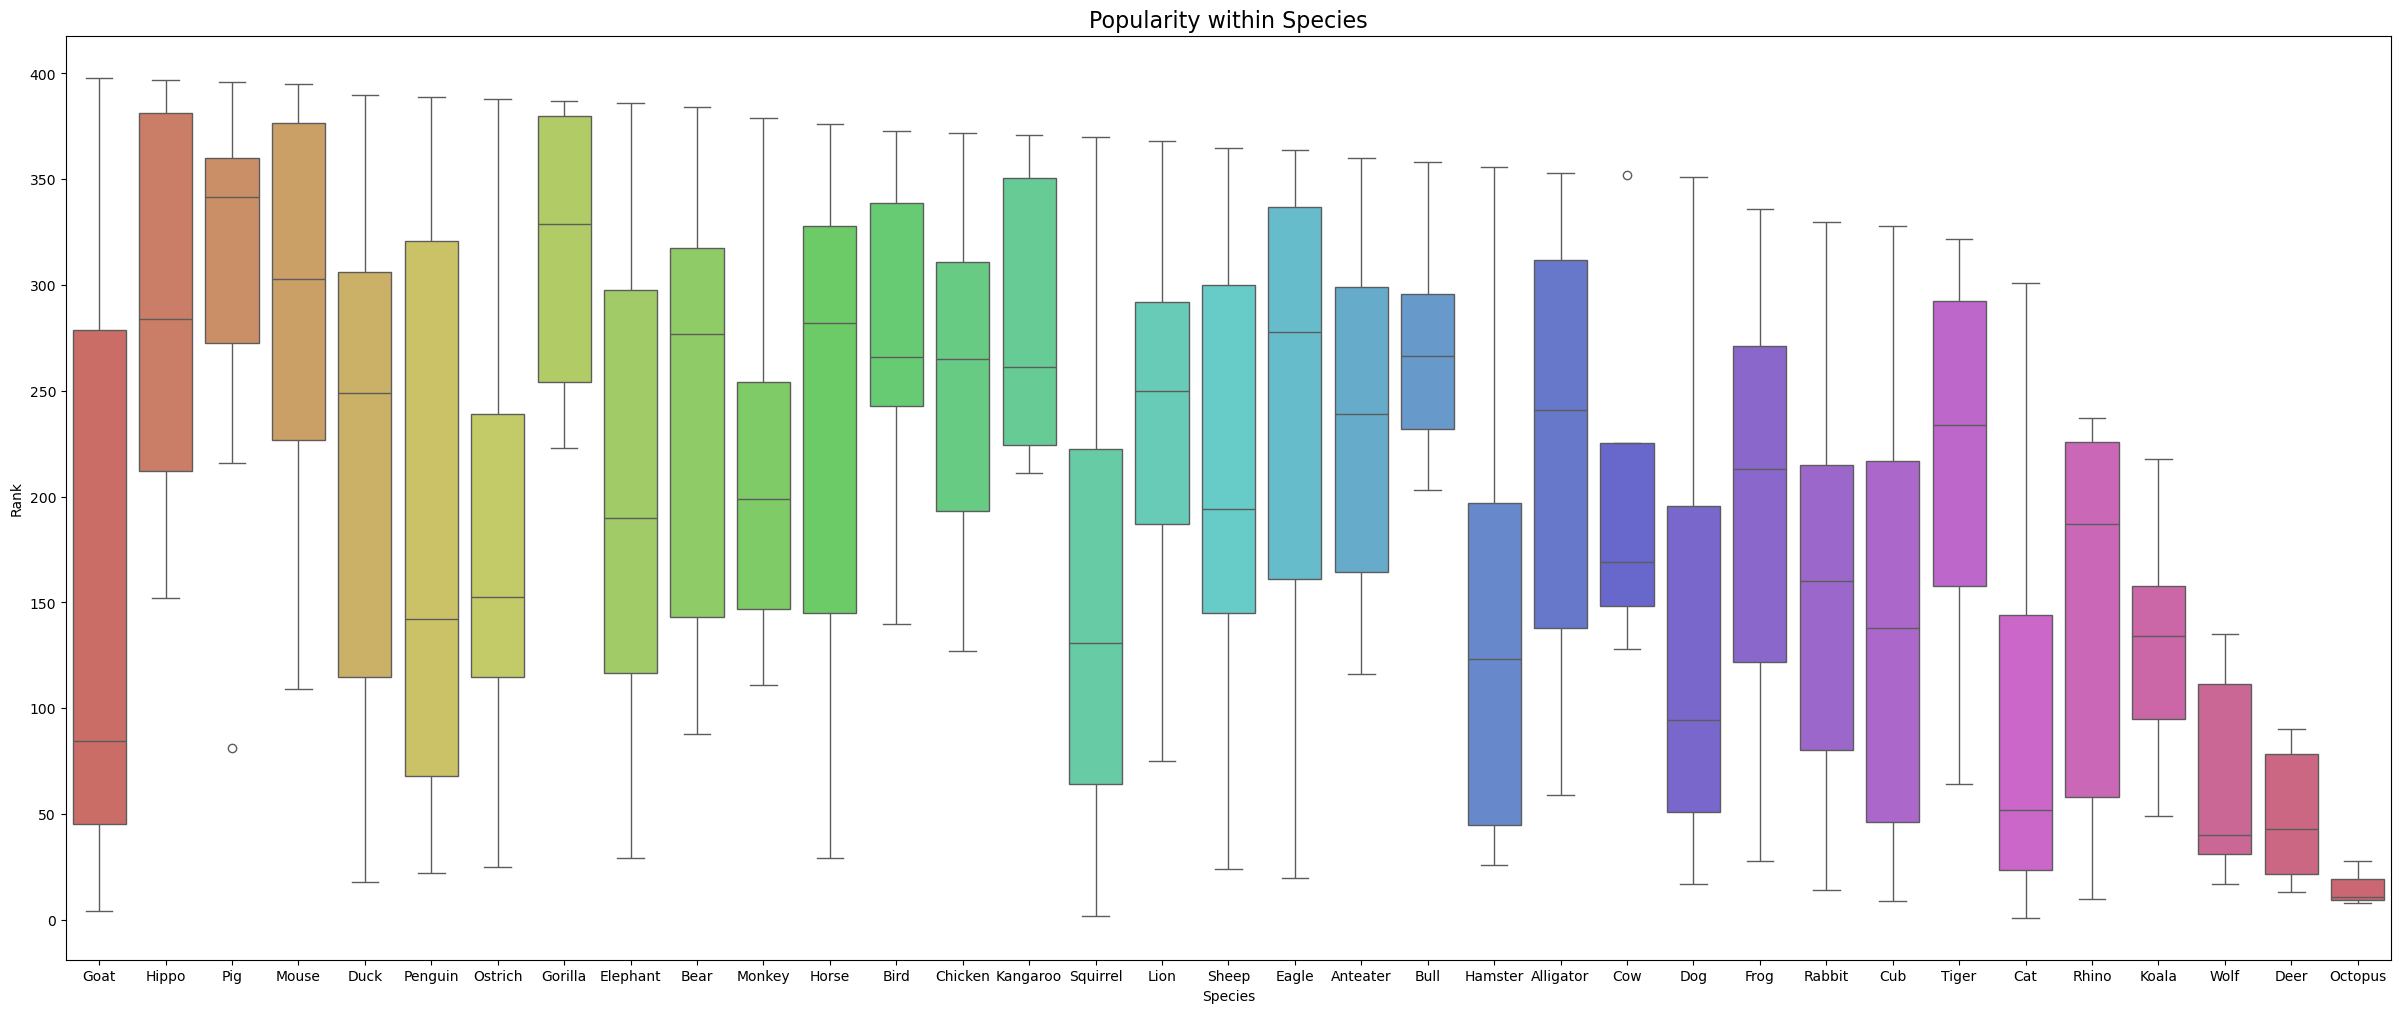

In [105]:
plt.figure(figsize=(30, 12))
sns.boxplot(x='Species', y='OverallRank', data=species, palette='hls')
plt.title('Popularity within Species', fontsize=16)
plt.xlabel('Species')
plt.ylabel('Rank')
plt.show()

The box plot is helpful in determining the range of popularity and which species may have outliers- for example, Agnes ranks 81, while the second-most popular pig, Gala, is all the way at 216. In contrast, Tipper the cow ranks 183, but the cow below her, Naomi, is all the way in 352!

### Part 2 - Average Species Popularity

In [106]:
speciesavg = pd.read_sql_query("""
    SELECT AVG(ranking.OverallRank) AS average_rank, villagers.Species
    FROM ranking
    JOIN villagers
        ON ranking.Name = villagers.Name
    GROUP BY Species
    ORDER BY average_rank ASC
""", conn)

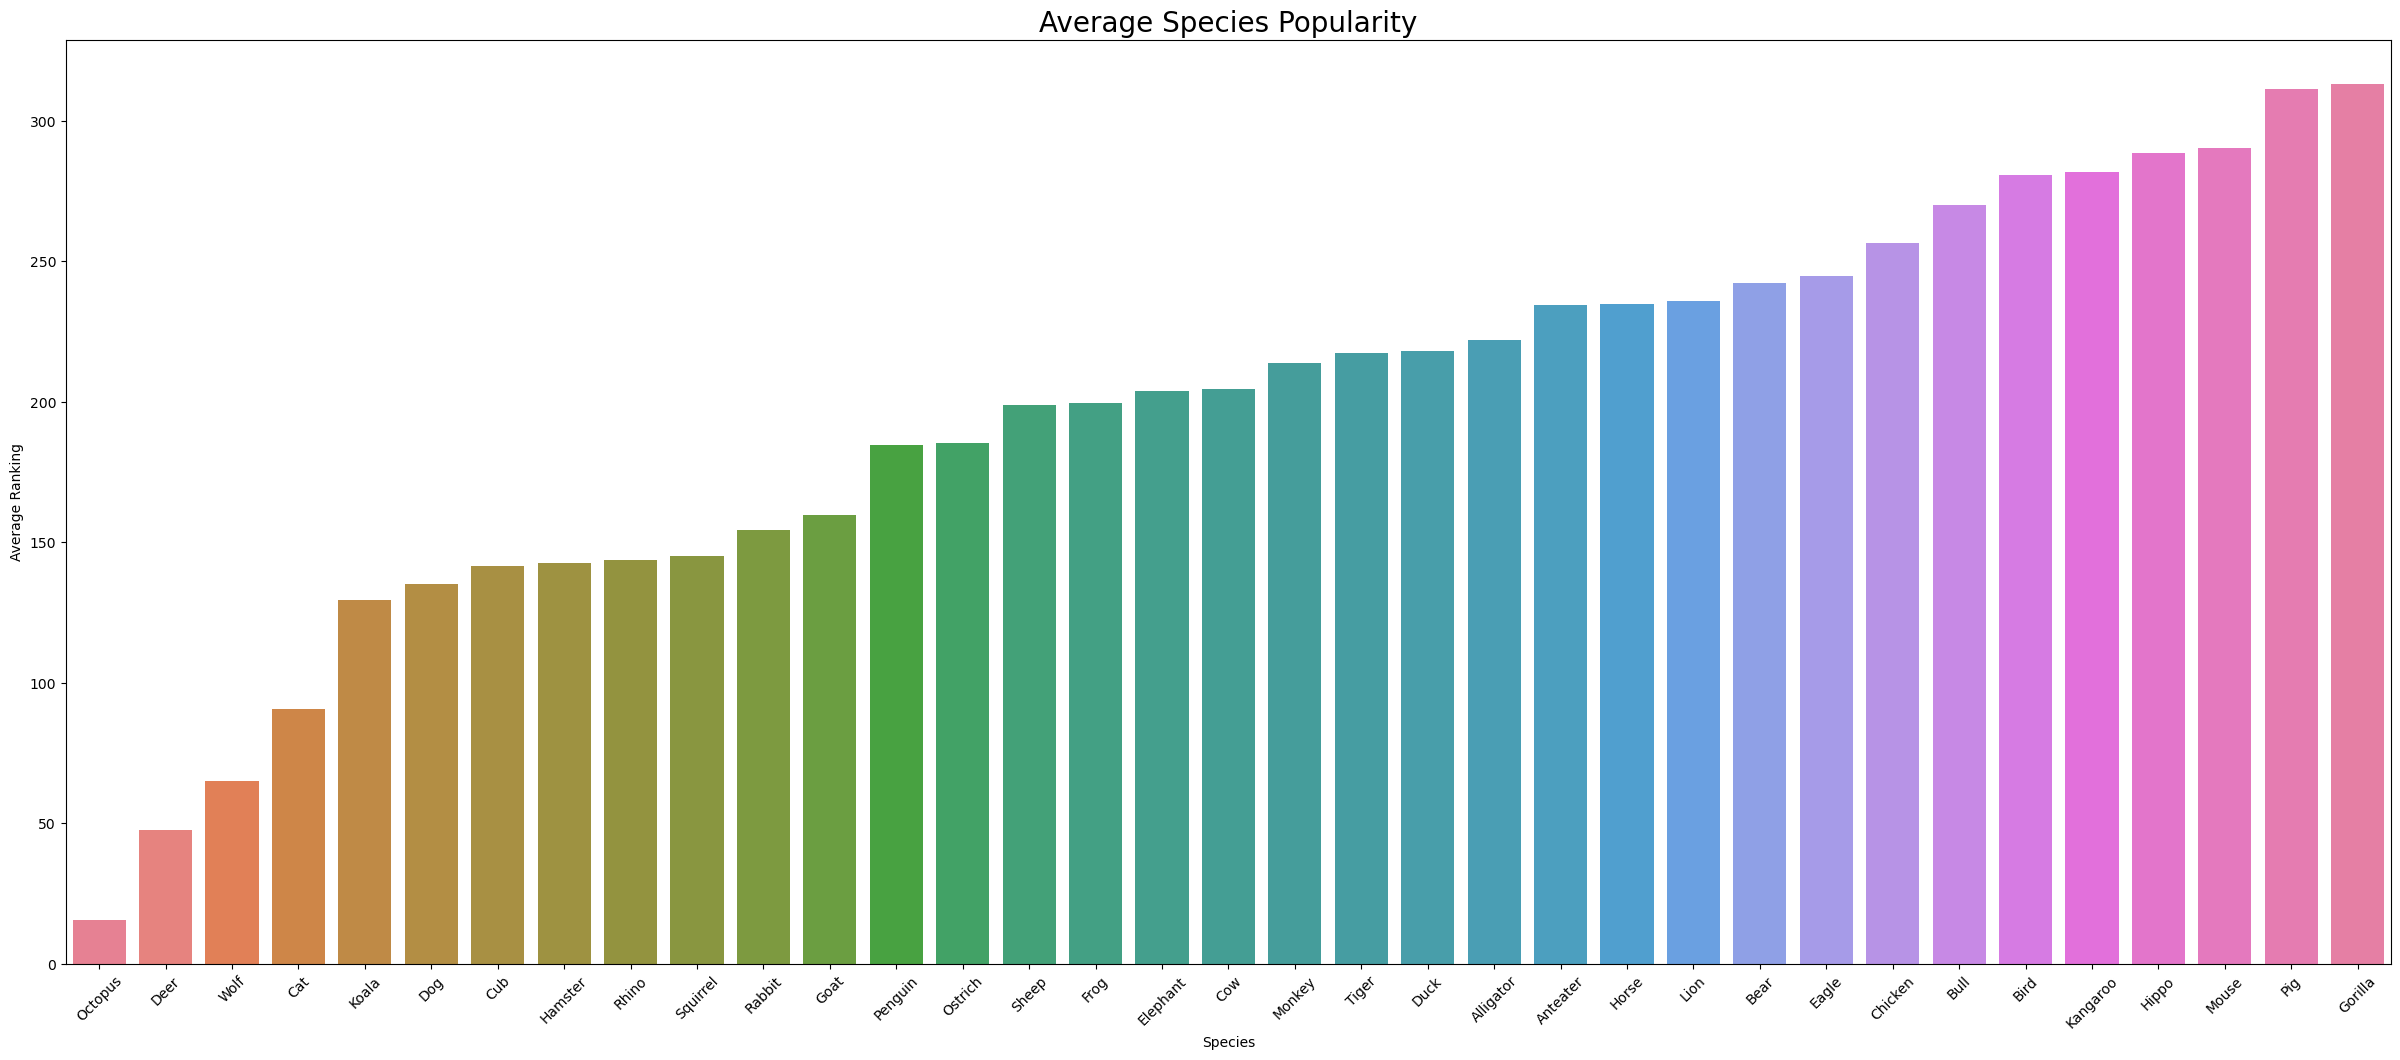

In [107]:
plt.figure(figsize=(30, 12))
sns.barplot(data=speciesavg, x='Species', y='average_rank', hue='Species', legend=False)
plt.title('Average Species Popularity', fontsize=20)
plt.xlabel('Species')
plt.ylabel('Average Ranking')
plt.xticks(rotation=45)
plt.show()

This graph is a followup to the previous, exploring the average popularity of each species, rather than the mean. I want the bars to be labelled with the species, but we'll get there when we get there- for now, you can cross-reference the data frame. I have more questions to ask, (like popularity vs. birth month, style/personality, etc.) but setting up these two graphs was already such a headache, haha. Part of me wonders if I should merge the ranking table into the villagers table externally just so I have one, easy table to work with, but at least I know how to use join functions in SQL now!

In [108]:
stylescombo = pd.read_sql_query("""
    SELECT AVG(ranking.OverallRank) AS average_rank, villagers.Style1, villagers.Style2
    FROM ranking
    JOIN villagers
        ON ranking.Name = villagers.Name
    GROUP BY Style1, Style2
    ORDER BY average_rank ASC
""", conn)
stylescombo

,average_rank,Style1,Style2
0,42.666667,Gorgeous,Simple
1,83.062500,Cute,Cute
2,90.000000,Gorgeous,Gorgeous
3,104.000000,Elegant,Elegant
4,115.870968,Simple,Cute
5,137.666667,Gorgeous,Cute
6,138.352941,Cute,Simple
7,141.285714,Elegant,Cute
8,155.800000,Active,Cute
9,159.000000,Cool,Elegant


In [109]:
heatmap_data = stylescombo.pivot_table(values='average_rank', index='Style2', columns='Style1')
heatmap_data.fillna(0)

Style1,Active,Cool,Cute,Elegant,Gorgeous,Simple
Style2,,,,,,
Active,243.833333,180.727273,171.500000,322.000000,191.000000,249.666667
Cool,227.222222,243.444444,0.000000,189.083333,201.750000,232.750000
Cute,155.800000,0.000000,83.062500,141.285714,137.666667,115.870968
Elegant,295.000000,159.000000,196.066667,104.000000,267.500000,223.818182
Gorgeous,323.500000,221.500000,265.571429,216.961538,90.000000,194.250000
Simple,236.920000,225.920000,138.352941,167.166667,42.666667,162.406250


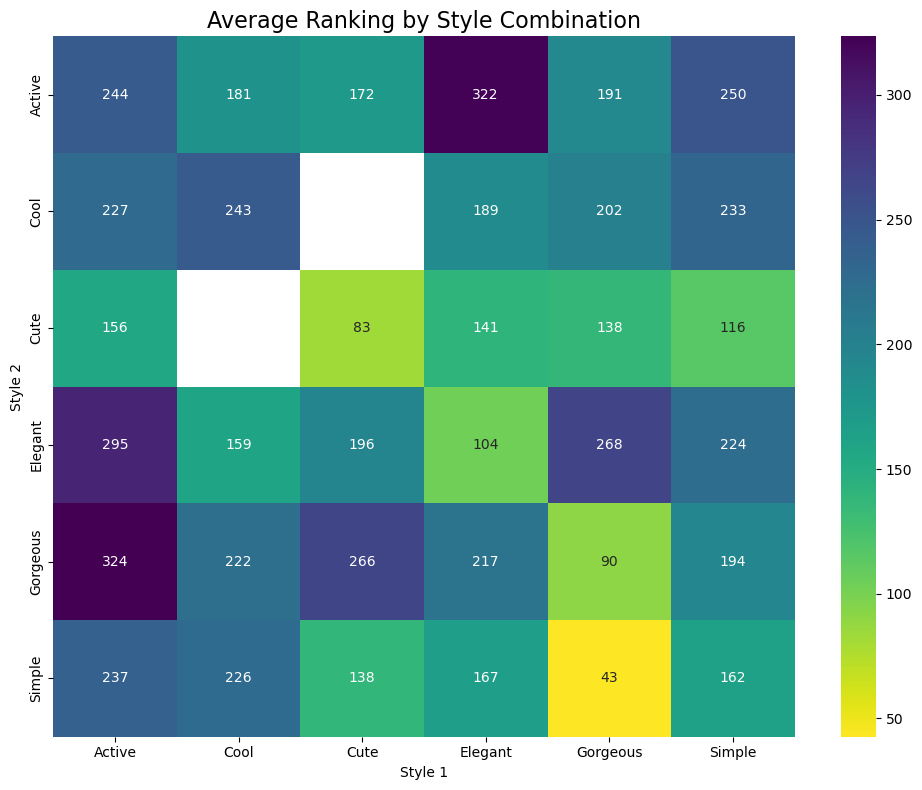

In [110]:
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='viridis_r', annot=True, fmt='.0f')
plt.title('Average Ranking by Style Combination', fontsize=16)
plt.xlabel('Style 1')
plt.ylabel('Style 2')
plt.tight_layout()
plt.show()

In [111]:
styleavg1 = pd.read_sql_query("""
    SELECT AVG(ranking.OverallRank) AS average_rank, villagers.Style1
    FROM ranking
    JOIN villagers
        ON ranking.Name = villagers.Name
    GROUP BY Style1
    ORDER BY average_rank ASC
""", conn)
styleavg1

,average_rank,Style1
0,156.396825,Cute
1,182.560345,Simple
2,197.222222,Elegant
3,211.940299,Cool
4,214.947368,Gorgeous
5,232.333333,Active


In [112]:
styleavg2 = pd.read_sql_query("""
    SELECT AVG(ranking.OverallRank) AS average_rank, villagers.Style2
    FROM ranking
    JOIN villagers
        ON ranking.Name = villagers.Name
    GROUP BY Style2
    ORDER BY average_rank ASC
""", conn)
styleavg2

,average_rank,Style2
0,114.548387,Cute
1,187.509259,Simple
2,219.458333,Active
3,220.241379,Cool
4,221.857143,Elegant
5,224.351852,Gorgeous


In [113]:
style = pd.DataFrame({
    'Style1': [156.40, 182.56, 197.22, 211.94, 214.95, 232.33],
    'Style2': [114.55, 187.51, 221.85, 220.24, 224.35, 219.46],
}, index=['Cute', 'Simple', 'Elegant', 'Cool', 'Gorgeous', 'Active'])
style['Average'] = (style['Style1'] + style['Style2']) / 2
style

,Style1,Style2,Average
Cute,156.40,114.55,135.475
Simple,182.56,187.51,185.035
Elegant,197.22,221.85,209.535
Cool,211.94,220.24,216.090
Gorgeous,214.95,224.35,219.650
Active,232.33,219.46,225.895


<Figure size 1000x600 with 0 Axes>

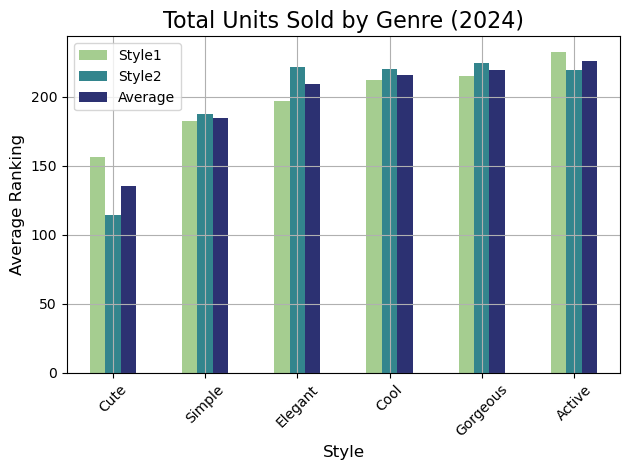

In [114]:
plt.figure(figsize=(10, 6))
style.plot(kind='bar', grid=True, cmap='crest')
plt.title('Total Units Sold by Genre (2024)', fontsize=16)
plt.xlabel('Style', fontsize=12)
plt.ylabel('Average Ranking', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()